In [6]:
!pip install h5py

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --------- ------------------------------ 0.8/3.2 MB 1.7 MB/s eta 0:00:02
   --------- ------------------------------ 0.8/3.2 MB 1.7 MB/s eta 0:00:02
   ----------------------- ---------------- 1.8/3.2 MB 2.3 MB/s eta 0:00:01
   -------------------------- ------------- 2.1/3.2 MB 2.0 MB/s eta 0:00:01
   -------------------------------- ------- 2.6/3.2 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 2.3 MB/s  0:00:01


In [61]:
import torch
import einops
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from einops import rearrange
from einops.layers.torch import Rearrange
from torch.utils.data import DataLoader, Dataset
import h5py

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

In [62]:
# Applies following operations:
# LayerNorm --> nn.Linear --> GELU --> Dropout -->nn.Linear --> Dropout

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super(FeedForward, self).__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [63]:
class AttentionBlock(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super(AttentionBlock, self).__init__()
        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)

        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)

        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        
        return self.to_out(out)

In [64]:
# 1. Applied depth times:1.1 Attention Block --> 1.2 MLP Block
# 2. Applied LayerNorm

class TransformerBlock(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim):
        super(TransformerBlock, self).__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                AttentionBlock(dim, heads = heads, dim_head = dim_head),
                FeedForward(dim, mlp_dim)
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

In [65]:
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

In [66]:
class ViT(nn.Module):
    def __init__(self,
                 image_size,
                 patch_size,
                 dim,
                 depth,
                 heads,
                 mlp_dim = 256,
                 channels = 1,
                 dim_head = 32,
                 emb_dropout = 0.):
        super(ViT, self).__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (c p1 p2)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim)
        )

        self.patch_to_image = nn.Sequential(
            nn.Linear(dim, patch_dim),
            nn.LayerNorm(patch_dim),
            Rearrange('b (h w) (c p1 p2) -> b c (h p1) (w p2)', p1 = patch_height, p2 = patch_width, h = image_height // patch_height) 
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = TransformerBlock(dim, depth, heads, dim_head, mlp_dim)
        
        self.conv = torch.nn.Conv2d(in_channels = channels,
                                    out_channels = channels,
                                    kernel_size = 3,
                                    padding = 1)
        
    def forward(self, img):
        x = self.to_patch_embedding(img)
        _, n, _ = x.shape
        x += self.pos_embedding[:, :n]
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.patch_to_image(x)
        x = self.conv(x)
        return x
    
    def print_size(self):
        nparams = 0
        nbytes = 0

        for param in self.parameters():
            nparams += param.numel()
            nbytes += param.data.element_size() * param.numel()

        print(f'Total number of model parameters: {nparams}')

        return nparams

In [67]:
# Dataloader

class AllenCahnDataset(Dataset):
    def __init__(self, which = "train", training_samples = 256):

        assert training_samples <= 256

        # default file
        self.file_data = "AllenCahn_NEW.h5"
        self.reader = h5py.File(self.file_data, "r")

        self.min_data = self.reader['min_u0'][()]
        self.max_data = self.reader['max_u0'][()]
        self.min_model = self.reader['min_u'][()]
        self.max_model = self.reader['max_u'][()]

        if which == "train":
            self.length = training_samples
            self.start = 0
        elif which == "val":
            self.length = 128 
            self.start = 256
        elif which == "test":
            self.length = 128
            self.start = 256 + 128
        else:
            raise ValueError("which must be one of 'train', 'val', 'test'")

        self.reader = h5py.File(self.file_data, "r")

    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        inputs = torch.from_numpy(self.reader['Sample_' + str(index + self.start)]["input"][:]).type(torch.float32).reshape(1, 64, 64)
        labels = torch.from_numpy(self.reader['Sample_' + str(index + self.start)]["output"][:]).type(torch.float32).reshape(1, 64, 64)

        inputs = (inputs - self.min_data) / (self.max_data - self.min_data)
        labels = (labels - self.min_model) / (self.max_model - self.min_model)

        return inputs, labels

In [68]:
training_samples = 256
batch_size = 16

train_dataset = AllenCahnDataset(which = "train", training_samples = training_samples)
val_dataset = AllenCahnDataset(which = "val")

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = True)

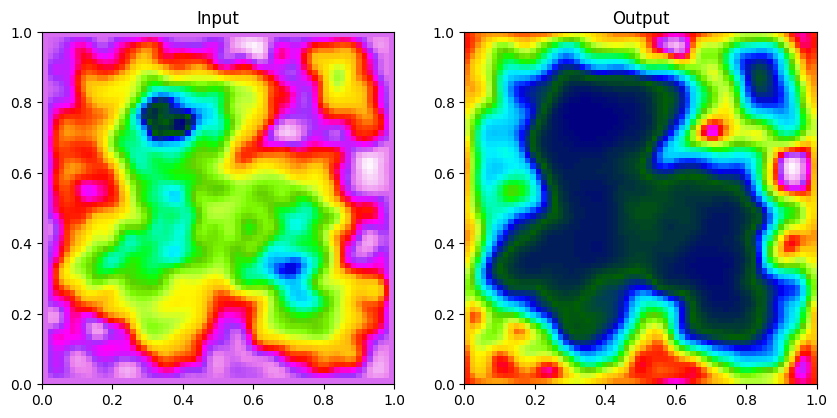

In [35]:
input, output = next(iter(train_loader))
input = input[0, 0].numpy()
output = output[0, 0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(input, cmap = "gist_ncar", extent = (0, 1, 0, 1))
axes[0].set_title("Input")
axes[1].imshow(output, cmap = "gist_ncar", extent = (0, 1, 0, 1))
axes[1].set_title("Output")
plt.show()

In [69]:
image_size = 64
patch_size = 16
dim = 128
depth = 4
heads = 4
dim_head = 32
emb_dropout = 0.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViT(image_size = image_size,
            patch_size = patch_size,
            dim = dim,
            depth = depth,
            heads = heads,
            mlp_dim = 256,
            channels = 1,
            dim_head = dim_head,
            emb_dropout = emb_dropout).to(device)

model.print_size()

Total number of model parameters: 597898


597898

In [76]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0 = 200, eta_min = 10**-6)
loss = nn.L1Loss()

epochs = 500

freq_print = 1
for epoch in range(epochs):
    train_mse = 0.0
    for step, (input_batch, output_batch) in enumerate(train_loader):
        input_batch = torch.tensor(input_batch).to(device)
        output_batch = torch.tensor(output_batch).to(device)
        optimizer.zero_grad()
        output_pred_batch = model(input_batch)
        loss_f = loss(output_pred_batch, output_batch) / loss(output_batch, torch.zeros_like(output_batch))
        loss_f.backward()
        optimizer.step()
        train_mse += loss_f.item()
    train_mse /= len(train_loader)

    scheduler.step()
    with torch.no_grad():
        model.eval()
        test_relative_l1 = 0.0
        for step, (input_batch, output_batch) in enumerate(val_loader):
            input_batch = torch.tensor(input_batch).to(device)
            output_batch = torch.tensor(output_batch).to(device)
            output_pred_batch = model(input_batch)
            loss_f = (torch.mean((abs(output_pred_batch - output_batch))) / torch.mean(abs(output_batch))) * 100
            test_relative_l1 += loss_f.item()
        test_relative_l1 /= len(val_loader)

    if epoch % freq_print == 0: print(f"## Epoch: {epoch}, ## Train MSE: {train_mse:.4f}, ## Test Relative L1: {test_relative_l1:.4f}")

C:\Users\72998\AppData\Local\Temp\ipykernel_3928\3433775234.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_batch = torch.tensor(input_batch).to(device)
C:\Users\72998\AppData\Local\Temp\ipykernel_3928\3433775234.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output_batch = torch.tensor(output_batch).to(device)
C:\Users\72998\AppData\Local\Temp\ipykernel_3928\3433775234.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_batch = torch.tensor(input_batch).to(device)
C:\Users\72998\AppData\Local\Temp\ipykernel_3928\3

## Epoch: 0, ## Train MSE: 0.3534, ## Test Relative L1: 39.0699
## Epoch: 1, ## Train MSE: 0.3452, ## Test Relative L1: 38.4153
## Epoch: 2, ## Train MSE: 0.3408, ## Test Relative L1: 38.3048
## Epoch: 3, ## Train MSE: 0.3393, ## Test Relative L1: 38.2343
## Epoch: 4, ## Train MSE: 0.3373, ## Test Relative L1: 37.5991
## Epoch: 5, ## Train MSE: 0.3325, ## Test Relative L1: 37.4963
## Epoch: 6, ## Train MSE: 0.3284, ## Test Relative L1: 37.1660
## Epoch: 7, ## Train MSE: 0.3246, ## Test Relative L1: 36.9140
## Epoch: 8, ## Train MSE: 0.3211, ## Test Relative L1: 35.9981
## Epoch: 9, ## Train MSE: 0.3183, ## Test Relative L1: 35.7245
## Epoch: 10, ## Train MSE: 0.3131, ## Test Relative L1: 35.4156
## Epoch: 11, ## Train MSE: 0.3135, ## Test Relative L1: 35.4605
## Epoch: 12, ## Train MSE: 0.3071, ## Test Relative L1: 35.9271
## Epoch: 13, ## Train MSE: 0.3052, ## Test Relative L1: 34.6563
## Epoch: 14, ## Train MSE: 0.3000, ## Test Relative L1: 34.3875
## Epoch: 15, ## Train MSE: 0.2989,

C:\Users\72998\AppData\Local\Temp\ipykernel_3928\1792614645.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(input).to(device)


Text(0.5, 1.0, 'Prediction')

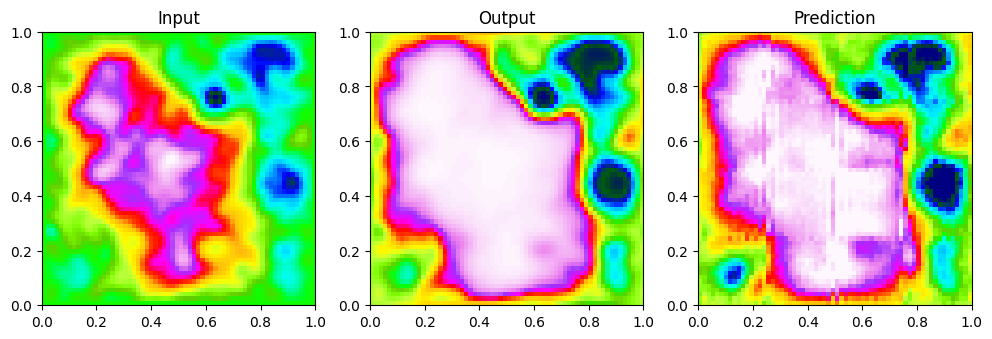

In [77]:
input, output = next(iter(val_loader))
input = torch.tensor(input).to(device)
pred = model(input)
input = input[0,0].cpu().numpy()
output = output[0,0].numpy()
pred = pred[0,0].detach().cpu().numpy()

vmin = np.min(output)
vmax = np.max(output)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(input, cmap = "gist_ncar", extent=(0,1,0,1),)
axes[0].set_title("Input")
axes[1].imshow(output, cmap = "gist_ncar", extent=(0,1,0,1), vmin = vmin, vmax= vmax)
axes[1].set_title("Output")
axes[2].imshow(pred, cmap = "gist_ncar", extent=(0,1,0,1), vmin = vmin, vmax= vmax)
axes[2].set_title("Prediction")